In [8]:
# Load the data
df = pd.read_csv('../data/online_retail.csv', encoding='latin1')

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custo

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [9]:
#check shape
print("Original shape:", df.shape)

Original shape: (541909, 8)


In [10]:
df = df.dropna(subset=['Description'])
print("After removing missing Description:", df.shape)

After removing missing Description: (540455, 8)


In [11]:
#handling missing customer id
df['CustomerID'] = df['CustomerID'].fillna('Unknown')
print("Missing CustomerIDs filled.")

Missing CustomerIDs filled.


In [12]:
#convert invoicedate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("InvoiceDate converted to datetime.")

InvoiceDate converted to datetime.


In [13]:
#Total price Column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print("TotalPrice column created.")

TotalPrice column created.


In [14]:

# Cancelled invoices usually start with 'C'
cancelled = df[df['InvoiceNo'].astype(str).str.contains('C')]
print("Number of cancelled transactions:", len(cancelled))

Number of cancelled transactions: 9288


In [17]:
#remove cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]
print("After removing cancelled orders:", df.shape)

After removing cancelled orders: (0, 9)


In [18]:
#Remove rows with Quantity <= 0 or UnitPrice <= 0
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print("After removing invalid Quantity/Price:", df.shape)


After removing invalid Quantity/Price: (0, 9)


In [19]:
#remove duplicates
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (0, 9)


In [20]:
#Create useful date columns
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

print("Date columns created successfully!")


Date columns created successfully!


In [21]:
print("Final shape:", df.shape)
df.isnull().sum()

Final shape: (0, 14)


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
Year           0
Month          0
Day            0
Hour           0
DayOfWeek      0
dtype: int64

In [22]:
# Save cleaned data
df.to_csv('../data/online_retail_cleaned.csv', index=False)
print("Cleaned data saved successfully!")

Cleaned data saved successfully!


In [1]:
import os
print("Current Directory:")
print(os.getcwd())

Current Directory:
C:\Users\USER\OneDrive\Desktop\Online Retail Analysis\Notebook


In [2]:
print("\nFiles and folders here:")
print(os.listdir())


Files and folders here:
['.ipynb_checkpoints', 'online_retail_analysis.ipynb']


In [3]:
import glob
print("\nSearching for the cleaned file:")
print(glob.glob("**/*cleaned*.csv", recursive=True))
print(glob.glob("**/*retail*.csv", recursive=True))


Searching for the cleaned file:
[]
[]


In [2]:
import mysql.connector
import pandas as pd

# Load the cleaned data
df = pd.read_csv('../data/online_retail_cleaned.csv')

# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Moitalel12',      
    database='online_retail'
)

cursor = conn.cursor()

# Clear the table first
cursor.execute("TRUNCATE TABLE retail_sales")

print("Connected successfully. Starting import.")

# Insert data
for index, row in df.iterrows():
    sql = """
    INSERT INTO retail_sales (
        InvoiceNo, StockCode, Description, Quantity, InvoiceDate,
        UnitPrice, CustomerID, Country, TotalPrice, Year, Month, Day, Hour, DayOfWeek
    ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """
    values = (
        str(row['InvoiceNo']),
        str(row['StockCode']),
        str(row['Description']),
        int(row['Quantity']),
        str(row['InvoiceDate']),
        float(row['UnitPrice']),
        str(row['CustomerID']),
        str(row['Country']),
        float(row['TotalPrice']),
        int(row['Year']),
        int(row['Month']),
        int(row['Day']),
        int(row['Hour']),
        str(row['DayOfWeek'])
    )
    cursor.execute(sql, values)

# Save changes
conn.commit()

print("Data imported successfully!")
print("Total rows inserted:", cursor.rowcount)

cursor.close()
conn.close()

Connected successfully. Starting import.
Data imported successfully!
Total rows inserted: 0


In [3]:
import pandas as pd

df = pd.read_csv('../data/online_retail_cleaned.csv')
print("Shape of the data:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape of the data: (0, 14)

First 5 rows:
Empty DataFrame
Columns: [InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country, TotalPrice, Year, Month, Day, Hour, DayOfWeek]
Index: []


In [4]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek']


In [5]:
print("Number of rows:", len(df))
print("Is DataFrame empty?", df.empty)

Number of rows: 0
Is DataFrame empty? True


In [6]:
import pandas as pd
import numpy as np

# 1. Load original data
df = pd.read_csv('../data/Online_Retail.csv', encoding='latin1')
print("Original shape:", df.shape)

# 2. Basic cleaning
df = df.dropna(subset=['Description'])                  # Remove missing descriptions
df['CustomerID'] = df['CustomerID'].fillna('Unknown')   # Fill missing CustomerID
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])   # Convert date

# 3. Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# 4. Remove cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.contains('C', na=False)]

# 5. Keep only positive Quantity and UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 6. Remove duplicates
df = df.drop_duplicates()

# 7. Create extra date columns
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

print("Cleaned shape:", df.shape)
print(df.head())

# 8. Save the cleaned file
df.to_csv('../data/online_retail_cleaned.csv', index=False)
print("Cleaned data saved successfully!")

Original shape: (541909, 8)
Cleaned shape: (524878, 14)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice CustomerID         Country  TotalPrice  Year  \
0 2010-12-01 08:26:00       2.55    17850.0  United Kingdom       15.30  2010   
1 2010-12-01 08:26:00       3.39    17850.0  United Kingdom       20.34  2010   
2 2010-12-01 08:26:00       2.75    17850.0  United Kingdom       22.00  2010   
3 2010-12-01 08:26:00       3.39    17850.0  United Kingdom       20.34  2010   
4 2010-12-01 08:26:00       3.39    17850.0  United Kingdom       20.34  2010   

   Month  Day  Hour  Day

In [8]:
import mysql.connector
import pandas as pd

# Load the newly cleaned data
df = pd.read_csv('../data/online_retail_cleaned.csv')
print("Data loaded. Shape:", df.shape)

# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Moitalel12',
    database='online_retail'
)

cursor = conn.cursor()

# Clear the table
cursor.execute("TRUNCATE TABLE retail_sales")

print("Starting import... Please wait (this will take several minutes)")

# Insert data
for index, row in df.iterrows():
    sql = """
    INSERT INTO retail_sales (
        InvoiceNo, StockCode, Description, Quantity, InvoiceDate,
        UnitPrice, CustomerID, Country, TotalPrice, Year, Month, Day, Hour, DayOfWeek
    ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """
    values = (
        str(row['InvoiceNo']),
        str(row['StockCode']),
        str(row['Description']),
        int(row['Quantity']),
        str(row['InvoiceDate']),
        float(row['UnitPrice']),
        str(row['CustomerID']),
        str(row['Country']),
        float(row['TotalPrice']),
        int(row['Year']),
        int(row['Month']),
        int(row['Day']),
        int(row['Hour']),
        str(row['DayOfWeek'])
    )
    cursor.execute(sql, values)

# Commit changes
conn.commit()

print("Import completed!")
print("Total rows inserted:", cursor.rowcount)

cursor.close()
conn.close()

C:\Users\USER\AppData\Local\Temp\ipykernel_12920\3900056767.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/online_retail_cleaned.csv')


Data loaded. Shape: (524878, 14)
Starting import... Please wait (this will take several minutes)
Import completed!
Total rows inserted: 1


In [9]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Moitalel12',
    database='online_retail'
)

print("Connected to MySQL successfully!")

Connected to MySQL successfully!


In [10]:
monthly_revenue = pd.read_sql("""
    SELECT Year, Month, ROUND(SUM(TotalPrice), 2) AS Revenue
    FROM retail_sales
    GROUP BY Year, Month
    ORDER BY Year, Month
""", conn)

print(monthly_revenue)

C:\Users\USER\AppData\Local\Temp\ipykernel_12920\2646431701.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_revenue = pd.read_sql("""


    Year  Month     Revenue
0   2010     12   821452.73
1   2011      1   689811.61
2   2011      2   522545.56
3   2011      3   716215.26
4   2011      4   536968.49
5   2011      5   769296.61
6   2011      6   760547.01
7   2011      7   718076.12
8   2011      8   757841.38
9   2011      9  1056435.19
10  2011     10  1151263.73
11  2011     11  1503866.78
12  2011     12   637790.33


In [11]:
top_countries = pd.read_sql("""
    SELECT Country, ROUND(SUM(TotalPrice), 2) AS Revenue
    FROM retail_sales
    GROUP BY Country
    ORDER BY Revenue DESC
    LIMIT 10
""", conn)

print(top_countries)

C:\Users\USER\AppData\Local\Temp\ipykernel_12920\2165613772.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_countries = pd.read_sql("""


          Country     Revenue
0  United Kingdom  9001744.09
1     Netherlands   285446.34
2            EIRE   283140.52
3         Germany   228678.40
4          France   209625.37
5       Australia   138453.81
6           Spain    61558.56
7     Switzerland    57067.60
8         Belgium    41196.34
9          Sweden    38367.83


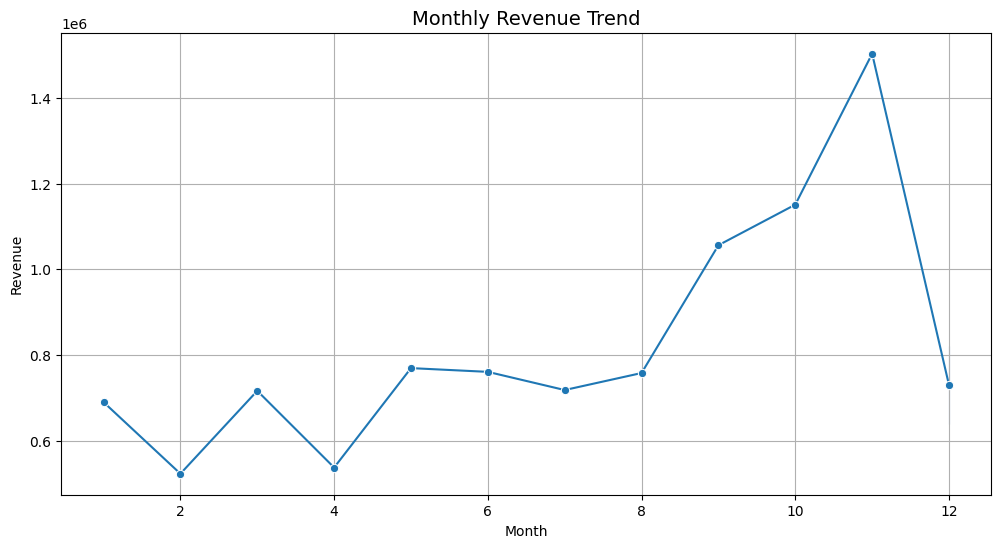

In [12]:
#Monthly trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x='Month', y='Revenue', marker='o')
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_12920\4205044834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='Revenue', y='Country', palette='viridis')


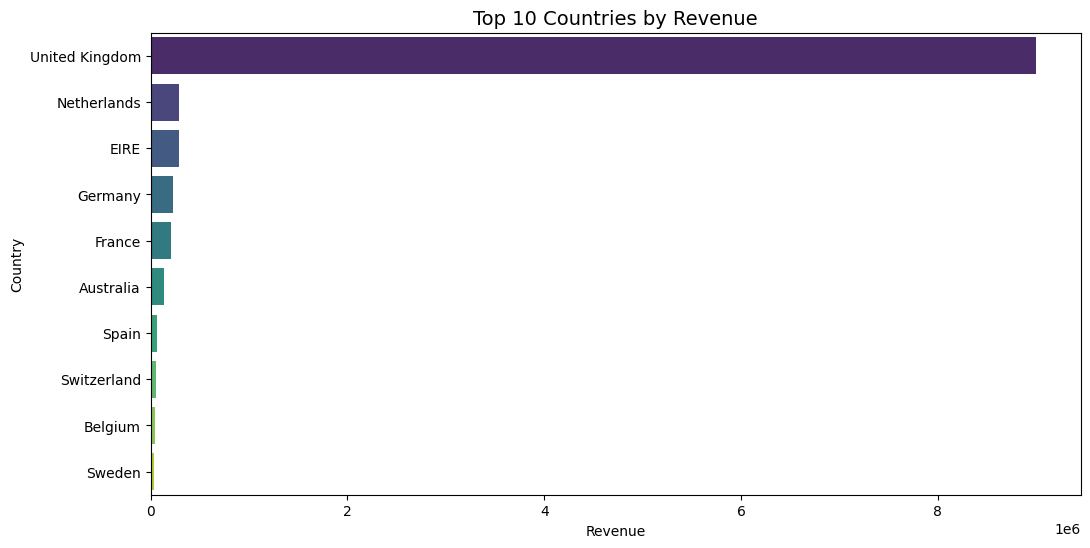

In [13]:
#Top 10 countries
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='Revenue', y='Country', palette='viridis')
plt.title('Top 10 Countries by Revenue', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.show()

In [14]:
#top products
top_products = pd.read_sql("""
    SELECT Description, 
           ROUND(SUM(TotalPrice), 2) AS Revenue,
           SUM(Quantity) AS Quantity_Sold
    FROM retail_sales
    GROUP BY Description
    ORDER BY Revenue DESC
    LIMIT 10
""", conn)

print(top_products)

C:\Users\USER\AppData\Local\Temp\ipykernel_12920\2859313790.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_products = pd.read_sql("""


                          Description    Revenue  Quantity_Sold
0                      DOTCOM POSTAGE  206248.77          706.0
1            REGENCY CAKESTAND 3 TIER  174156.54        13851.0
2         PAPER CRAFT , LITTLE BIRDIE  168469.60        80995.0
3  WHITE HANGING HEART T-LIGHT HOLDER  106236.72        37872.0
4                       PARTY BUNTING   99445.23        18283.0
5             JUMBO BAG RED RETROSPOT   94159.81        48371.0
6      MEDIUM CERAMIC TOP STORAGE JAR   81700.92        78033.0
7                             POSTAGE   78101.88         3150.0
8                              Manual   77752.82         6985.0
9                  RABBIT NIGHT LIGHT   66870.03        30739.0


In [15]:
#top 10 customers by spending
top_customers = pd.read_sql("""
    SELECT CustomerID,
           ROUND(SUM(TotalPrice), 2) AS Total_Spent,
           COUNT(DISTINCT InvoiceNo) AS Orders
    FROM retail_sales
    WHERE CustomerID != 'Unknown'
    GROUP BY CustomerID
    ORDER BY Total_Spent DESC
    LIMIT 10
""", conn)

print(top_customers)

C:\Users\USER\AppData\Local\Temp\ipykernel_12920\1213615086.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_customers = pd.read_sql("""


  CustomerID  Total_Spent  Orders
0    14646.0    280206.02      73
1    18102.0    259657.30      60
2    17450.0    194390.79      46
3    16446.0    168472.50       2
4    14911.0    143711.17     201
5    12415.0    124914.53      21
6    14156.0    117210.08      55
7    17511.0     91062.38      31
8    16029.0     80850.84      63
9    12346.0     77183.60       1


In [16]:
# Create Excel writer
with pd.ExcelWriter('../Excel/online_retail_summary.xlsx') as writer:
    monthly_revenue.to_excel(writer, sheet_name='Monthly Revenue', index=False)
    top_countries.to_excel(writer, sheet_name='Top Countries', index=False)
    top_products.to_excel(writer, sheet_name='Top Products', index=False)
    top_customers.to_excel(writer, sheet_name='Top Customers', index=False)

print("Excel file saved successfully as 'online_retail_summary.xlsx'")

ModuleNotFoundError: No module named 'openpyxl'

In [17]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
with pd.ExcelWriter('../Excel/online_retail_summary.xlsx') as writer:
    monthly_revenue.to_excel(writer, sheet_name='Monthly Revenue', index=False)
    top_countries.to_excel(writer, sheet_name='Top Countries', index=False)
    top_products.to_excel(writer, sheet_name='Top Products', index=False)
    top_customers.to_excel(writer, sheet_name='Top Customers', index=False)

print("Excel file saved successfully!")

Excel file saved successfully!


# Key Insights & Recommendations

## Key Insights

1. The **United Kingdom** accounts for the vast majority of revenue, far ahead of other countries.
2. Revenue shows clear monthly variation — useful for inventory and marketing planning.
3. A small number of customers contribute a very large share of total revenue (high-value customers).
4. Certain products generate significantly higher revenue and quantity sold than others.
5. There are customers with extremely high total spending (some over £200,000).

## Business Recommendations

1. **Focus on high-value customers** – Create loyalty programs or personalized offers for the top customers.
2. **Market expansion** – Explore growth opportunities in high-potential countries like Netherlands, EIRE, Germany, and France.
3. **Product strategy** – Push top-performing products and consider bundling them.
4. **Inventory planning** – Use monthly revenue trends to improve stock management.
5. **Customer retention** – Investigate why some high-spending customers have very few orders (e.g. Customer 16446 and 12346).